Copyright © 2024, Andrea Mastropietro. All rights reserved.

This code is licensed under the MIT License.

See the LICENSE file in the project root for more information.

## Analysis of anchor and non-anchor atoms using a control based on E(3)-transformations (distance-based vs Coulomb-matrix based)

In [1]:
import os
os.environ["http_proxy"] = "http://web-proxy.informatik.uni-bonn.de:3128"
os.environ["https_proxy"] = "http://web-proxy.informatik.uni-bonn.de:3128"

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
# Standard library imports
import copy
import os

# Third-party imports
import yaml
import torch
import numpy as np

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
from src.difflinker.datasets import get_dataloader
from src.difflinker.lightning import DDPM

In [3]:
with open('../config.yml', 'r') as file:
    config = yaml.safe_load(file)

checkpoint = "../" + config['CHECKPOINT']
DATA_FOLDER = "../" + config['DATA_FOLDER']
DATASET_NAME = config['DATASET_NAME']
device = config['DEVICE'] if torch.cuda.is_available() else 'cpu'
NUM_SAMPLES = config['NUM_SAMPLES']
P = config['P']
ATOM_TYPE_PERTURBATION = config['ATOM_TYPE_PERTURBATION']

SAVE_PLOT_FOLDER = "../results/plots/transformations_control/"
SHAPLEY_VALUE_FOLDER = f"../results/explanations/{DATASET_NAME}/" 
POSITIONS_FOLDER = f"../results/explanations/{DATASET_NAME}/" 

if ATOM_TYPE_PERTURBATION:
    SAVE_PLOT_FOLDER += "including_atom_type_perturbation/"
    
os.makedirs(SAVE_PLOT_FOLDER, exist_ok=True)

Load model to load the data

In [4]:
model = DDPM.load_from_checkpoint(checkpoint, map_location=device)
model.val_data_prefix = DATASET_NAME

print(f"Running device: {device}")

model.data_path = DATA_FOLDER

model = model.eval().to(device)
model.setup(stage='val')
dataloader = get_dataloader(
    model.val_dataset,
    batch_size=1
)

/home/mastropietro/anaconda3/envs/diff_explainer/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Lightning automatically

Running device: cuda:0


Load data samples for fragment, linker and anchor indices

In [5]:
data_list = []
sampled = 0
data_dict = {}
for data in dataloader:
    if sampled < NUM_SAMPLES:
        data_list.append(data)
        sampled += 1

#print all fragment masks, linker masks, and anchor masks
for i in range(len(data_list)):
    data_dict[i] = {}
    data_dict[i]["fragment_mask"] = data_list[i]['fragment_mask'].squeeze(0)
    data_dict[i]["linker_mask"] = data_list[i]['linker_mask'].squeeze(0)
    data_dict[i]["anchors"] = data_list[i]['anchors'].squeeze(0)


### Analyzing distance-based Shapley values

Read Shapley values from disk

In [6]:
seed_list = [42]
# STRATEGY = "hausdorff_distance"
for seed in seed_list:
    for i in range(NUM_SAMPLES):
        with open(f"{SHAPLEY_VALUE_FOLDER}explanations_seed_{str(seed)}/including_atom_type_perturbation/shapley_values/shapley_values_atoms_{i}.txt", "r") as f:
            f.readline()
            f.readline()
            shapley_values = []
            for line in f:
                if line == "\n":
                    break
                row = line.strip().split(",")
                shapley_values.append(float(row[1]))
            dict_key_name = f"shapley_values_{seed}"
            data_dict[i][dict_key_name] = shapley_values


read final positions from disk

In [7]:
for seed in seed_list:
    for i in range(NUM_SAMPLES):
        with open(f"{POSITIONS_FOLDER}explanations_seed_{str(seed)}/including_atom_type_perturbation/mapping/graphs/{i}/{i}_0_.xyz", "r") as f: #file with final atom positions
            num_atoms = int(f.readline().strip())
            f.readline()
            positions = []*num_atoms
            for line in f:
                row = line.strip().split(" ")[1:]
                coords = [float(x) for x in row]
                positions.append(coords)
            dict_key_name = f"positions_{seed}"
            data_dict[i][dict_key_name] = positions

Compute center of mass of linker atoms

In [8]:
for i in range(len(data_list)):
    linker_mask = data_dict[i]['linker_mask'].bool().cpu().numpy()
    for seed in seed_list:
        dict_key_name = f"positions_{seed}"
        positions = np.array(data_dict[i][dict_key_name])
        linker_positions = positions[linker_mask.squeeze()]
        com_linker = np.mean(linker_positions, axis=0)
        dict_key_name = f"com_linker_{seed}"
        data_dict[i][dict_key_name] = com_linker

Compute distance between fragment atoms and linker COM

In [9]:
for i in range(len(data_list)):
    fragment_mask = data_dict[i]['fragment_mask'].bool().cpu().numpy()
    for seed in seed_list:
        fragment_positions = np.array(data_dict[i][f'positions_{seed}'])[fragment_mask.squeeze()]
        com_linker = data_dict[i][f'com_linker_{seed}']
        distances = np.linalg.norm(fragment_positions - com_linker, axis=1)
        dict_key_name = f'distances_{seed}'
        data_dict[i][dict_key_name] = distances

Boxplot generation

In [10]:
for i in range(len(data_list)):
    for seed in seed_list:
        dict_key_name = f"shapley_values_{seed}"
        shapley_values = -np.array(data_dict[i][dict_key_name])
        min_val = np.min(shapley_values)
        max_val = np.max(shapley_values)
        normalized_shapley_values = 2 * (shapley_values - min_val) / (max_val - min_val) - 1
        dict_key_name = f"normalized_shapley_values_{seed}"
        data_dict[i][dict_key_name] = normalized_shapley_values.tolist()

In [11]:
for i in range(len(data_list)):
    for seed in seed_list:
        dict_key_name = f'distances_{seed}'
        distances = np.array(data_dict[i][dict_key_name])
        min_dist = np.min(distances)
        max_dist = np.max(distances)
        normalized_distances = (distances - min_dist) / (max_dist - min_dist)
        dict_key_name = f'normalized_distances_{seed}'
        data_dict[i][dict_key_name] = normalized_distances.tolist()

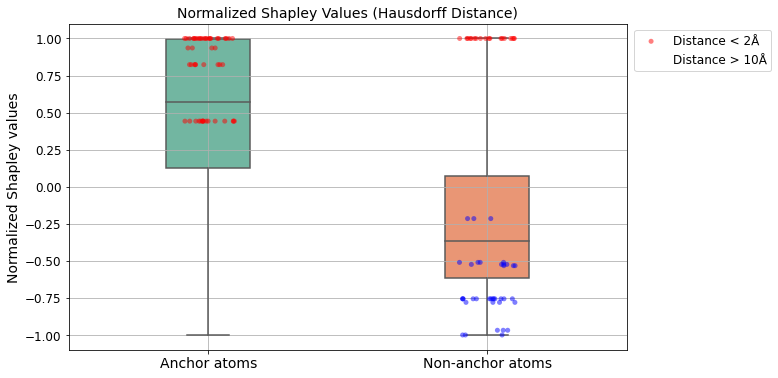

In [12]:
anchor_shapley_values = []
distances_anchor = []
non_anchor_shapley_values = []
distances_non_anchor = []
highlighted_shapley_values_close = []
highlighted_shapley_values_far = []

highlighted_shapley_values_close_non_anchor = []
highlighted_shapley_values_far_non_anchor = []

highlighted_middle_shapley_values = []
highlighted_middle_shapley_values_non_anchor = []

threshold_close = 2 
threshold_close_non_anchor = 2
threshold_far = 10

for i in range(len(data_list)):
    for seed in seed_list:
        anchor_mask = data_dict[i]['anchors'].bool().cpu().numpy()
        fragment_mask = data_dict[i]['fragment_mask'].bool().cpu().numpy()
        anchor_mask = anchor_mask[fragment_mask]
        distances = np.array(data_dict[i][f'distances_{seed}'])
        shapley_values = np.array(data_dict[i][f'normalized_shapley_values_{seed}'])
        
        anchor_shapley_values.extend(shapley_values[anchor_mask])
        distances_anchor.extend(distances[anchor_mask])
        non_anchor_shapley_values.extend(shapley_values[~anchor_mask])
        distances_non_anchor.extend(distances[~anchor_mask])
        # Highlight atoms whose distance is lower than the threshold for anchor atoms
        highlighted_shapley_values_close.extend(np.array(anchor_shapley_values)[np.array(distances_anchor) < threshold_close])
        highlighted_shapley_values_far.extend(np.array(anchor_shapley_values)[np.array(distances_anchor) > threshold_far])

        # Highlight atoms whose distance is lower than the threshold for non-anchor atoms
        highlighted_shapley_values_close_non_anchor.extend(np.array(non_anchor_shapley_values)[np.array(distances_non_anchor) <= threshold_close_non_anchor])
        highlighted_shapley_values_far_non_anchor.extend(np.array(non_anchor_shapley_values)[np.array(distances_non_anchor) >= threshold_far])

# Create box plot using seaborn

plt.figure(figsize=(10, 6))
sns.boxplot(data=[anchor_shapley_values, non_anchor_shapley_values], palette="Set2", width=0.3)
sns.stripplot(data=[highlighted_shapley_values_close, highlighted_shapley_values_close_non_anchor], color='red', alpha=0.5, label='Distance < 2Å')
sns.stripplot(data=[highlighted_shapley_values_far, highlighted_shapley_values_far_non_anchor], color='blue', alpha=0.5, label='Distance > 10Å')

plt.xticks([0, 1], ['Anchor atoms', 'Non-anchor atoms'], fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel('Normalized Shapley values', fontsize=14)
plt.title('Normalized Shapley Values (Hausdorff Distance)', fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()

unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)


plt.legend(unique_handles, unique_labels, loc='upper right', bbox_to_anchor=(1.27, 1), fontsize=12)

plt.grid(True)
plt.savefig(f"{SAVE_PLOT_FOLDER}box_plot_shapley_value_no_transformations_hausdorff_distance.pdf", bbox_inches='tight', dpi=300)
plt.savefig(f"{SAVE_PLOT_FOLDER}box_plot_shapley_value_no_transformations_hausdorff_distance.png", bbox_inches='tight', dpi=300)


Considering E(3)-transformations

In [13]:
seed = 42
transform_seed_list = [42]
data_dict_transform = copy.deepcopy(data_dict)
for t_seed in transform_seed_list:
    for i in range(NUM_SAMPLES):
        with open(f"{SHAPLEY_VALUE_FOLDER}explanations_seed_{seed}_rotate_translate_reflect/including_atom_type_perturbation/shapley_values/shapley_values_atoms_{i}.txt", "r") as f:
            f.readline()
            f.readline()
            shapley_values = []
            for line in f:
                if line == "\n":
                    break
                row = line.strip().split(",")
                shapley_values.append(float(row[1]))
            dict_key_name = f"shapley_values_{t_seed}"
            data_dict_transform[i][dict_key_name] = shapley_values

In [14]:
for t_seed in transform_seed_list:
    for i in range(NUM_SAMPLES):
        with open(f"{POSITIONS_FOLDER}explanations_seed_{str(seed)}_rotate_translate_reflect/including_atom_type_perturbation/mapping/graphs/{i}/{i}_0_.xyz", "r") as f:
            num_atoms = int(f.readline().strip())
            f.readline()
            positions = []*num_atoms
            for line in f:
                row = line.strip().split(" ")[1:]
                coords = [float(x) for x in row]
                positions.append(coords)
            dict_key_name = f"positions_{t_seed}"
            data_dict_transform[i][dict_key_name] = positions

In [15]:
for i in range(len(data_list)):
    linker_mask = data_dict_transform[i]['linker_mask'].bool().cpu().numpy()
    for t_seed in transform_seed_list:
        dict_key_name = f"positions_{t_seed}"
        positions = np.array(data_dict_transform[i][dict_key_name])
        linker_positions = positions[linker_mask.squeeze()]
        com_linker = np.mean(linker_positions, axis=0)
        dict_key_name = f"com_linker_{t_seed}"
        data_dict_transform[i][dict_key_name] = com_linker

In [16]:
for i in range(len(data_list)):
    fragment_mask = data_dict_transform[i]['fragment_mask'].bool().cpu().numpy()
    
    for t_seed in transform_seed_list:
        fragment_positions = np.array(data_dict_transform[i][f'positions_{seed}'])[fragment_mask.squeeze()]
        com_linker = data_dict_transform[i][f'com_linker_{t_seed}']
        distances = np.linalg.norm(fragment_positions - com_linker, axis=1)
        dict_key_name = f'distances_{t_seed}'
        data_dict_transform[i][dict_key_name] = distances

In [17]:
for i in range(len(data_list)):
    for t_seed in transform_seed_list:
        dict_key_name = f"shapley_values_{t_seed}"
        shapley_values = -np.array(data_dict_transform[i][dict_key_name])
        min_val = np.min(shapley_values)
        max_val = np.max(shapley_values)
        normalized_shapley_values = 2 * (shapley_values - min_val) / (max_val - min_val) - 1
        dict_key_name = f"normalized_shapley_values_{t_seed}"
        data_dict_transform[i][dict_key_name] = normalized_shapley_values.tolist()

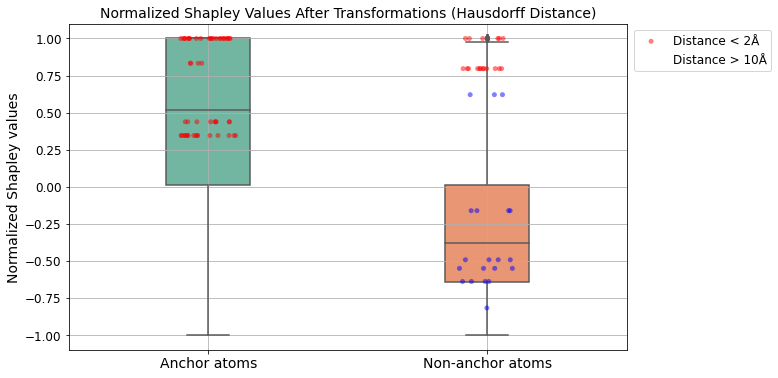

In [18]:
anchor_shapley_values_transform = []
distances_anchor_transform = []
non_anchor_shapley_values_transform = []
distances_non_anchor_transform = []
highlighted_shapley_values_close_transform = []
highlighted_shapley_values_far_transform = []

highlighted_shapley_values_close_transform_non_anchor = []
highlighted_shapley_values_far_non_anchor_transform = []

highlighted_middle_shapley_values_transform = []
highlighted_middle_shapley_values_transform_non_anchor = []

threshold_close = 2  # Define the threshold for distance
threshold_close_non_anchor = 2
threshold_far = 10

for i in range(len(data_list)):
    for t_seed in transform_seed_list:
        anchor_mask = data_dict_transform[i]['anchors'].bool().cpu().numpy()
        fragment_mask = data_dict_transform[i]['fragment_mask'].bool().cpu().numpy()
        anchor_mask = anchor_mask[fragment_mask]
        distances = np.array(data_dict_transform[i][f'distances_{t_seed}'])
        shapley_values = np.array(data_dict_transform[i][f'normalized_shapley_values_{t_seed}'])
        
        anchor_shapley_values_transform.extend(shapley_values[anchor_mask])
        distances_anchor_transform.extend(distances[anchor_mask])
        non_anchor_shapley_values_transform.extend(shapley_values[~anchor_mask])
        distances_non_anchor_transform.extend(distances[~anchor_mask])
        # Highlight atoms whose distance is lower than the threshold for anchor atoms
        highlighted_shapley_values_close_transform.extend(np.array(anchor_shapley_values_transform)[np.array(distances_anchor_transform) < threshold_close])
        highlighted_shapley_values_far_transform.extend(np.array(anchor_shapley_values_transform)[np.array(distances_anchor_transform) > threshold_far])

        # Highlight atoms whose distance is lower than the threshold for non-anchor atoms
        highlighted_shapley_values_close_transform_non_anchor.extend(np.array(non_anchor_shapley_values_transform)[np.array(distances_non_anchor_transform) <= threshold_close_non_anchor])
        highlighted_shapley_values_far_non_anchor_transform.extend(np.array(non_anchor_shapley_values_transform)[np.array(distances_non_anchor_transform) >= threshold_far])


# Create box plot using seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=[anchor_shapley_values_transform, non_anchor_shapley_values_transform], palette="Set2", width=0.3)
# sns.stripplot(data=[anchor_shapley_values_transform, non_anchor_shapley_values_transform], color='black', alpha=0.5)
sns.stripplot(data=[highlighted_shapley_values_close_transform, highlighted_shapley_values_close_transform_non_anchor], color='red', alpha=0.5, label='Distance < 2Å')

sns.stripplot(data=[highlighted_shapley_values_far_transform, highlighted_shapley_values_far_non_anchor_transform], color='blue', alpha=0.5, label='Distance > 10Å')

plt.xticks([0, 1], ['Anchor atoms', 'Non-anchor atoms'], fontsize=14)
plt.ylabel('Normalized Shapley values', fontsize=14)
plt.yticks(fontsize=12)
plt.title('Normalized Shapley Values After Transformations (Hausdorff Distance)', fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()

# Filter out the duplicate labels
unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)


plt.legend(unique_handles, unique_labels, loc='upper right', bbox_to_anchor=(1.27, 1), fontsize=12)

plt.grid(True)
plt.savefig(f"{SAVE_PLOT_FOLDER}box_plot_shapley_value_e3_transformations_hausdorff_distance.pdf", bbox_inches='tight', dpi=300)
plt.savefig(f"{SAVE_PLOT_FOLDER}box_plot_shapley_value_e3_transformations_hausdorff_distance.png", bbox_inches='tight', dpi=300)

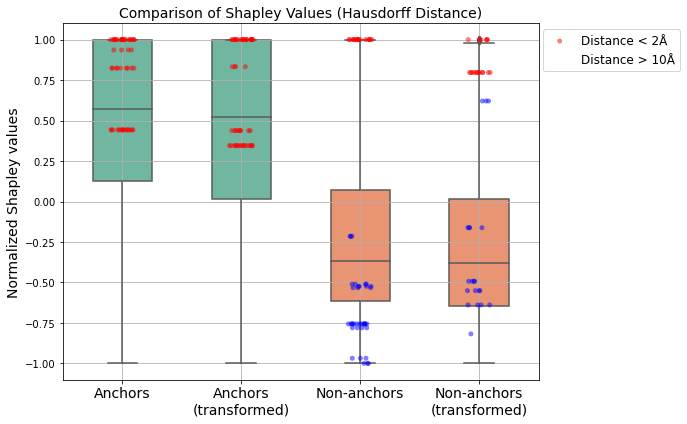

In [19]:
# Create a single plot for comparison
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=[anchor_shapley_values, anchor_shapley_values_transform, non_anchor_shapley_values, non_anchor_shapley_values_transform], 
            palette=[(0.4, 0.76, 0.65, 1), (0.4, 0.76, 0.65, 1), (0.99, 0.55, 0.38, 1), (0.99, 0.55, 0.38, 1)], width=0.5, ax=ax)

sns.stripplot(data=[highlighted_shapley_values_close, highlighted_shapley_values_close_transform, highlighted_shapley_values_close_non_anchor, highlighted_shapley_values_close_transform_non_anchor], color='red', alpha=0.5, label='Distance < 2Å', ax=ax, jitter=True)

sns.stripplot(data=[highlighted_shapley_values_far,  highlighted_shapley_values_far_transform, highlighted_shapley_values_far_non_anchor, highlighted_shapley_values_far_non_anchor_transform], color='blue', alpha=0.5, label='Distance > 10Å', ax=ax, jitter=True)


# Set labels and title
ax.set_xticks([0, 1,2,3])
ax.set_xticklabels(['Anchors', 'Anchors\n(transformed)', 'Non-anchors', 'Non-anchors\n(transformed)'], fontsize=14)
ax.set_ylabel('Normalized Shapley values', fontsize=14)
ax.set_title('Comparison of Shapley Values (Hausdorff Distance)', fontsize=14)
ax.grid(True)

# Add a shared legend
handles, labels = ax.get_legend_handles_labels()
unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)
ax.legend(unique_handles, unique_labels, loc='upper right', fontsize=12, bbox_to_anchor=(1.31, 1))

# Save and show the plot
plt.tight_layout()
plt.savefig(f"{SAVE_PLOT_FOLDER}comparison_shapley_values_original_vs_transform_hausdorff_distance.pdf", bbox_inches='tight', dpi=300)
plt.savefig(f"{SAVE_PLOT_FOLDER}comparison_shapley_values_original_vs_transform_hausdorff_distance.png", bbox_inches='tight', dpi=300)
plt.show()


### Analyzing Coulomb-matrix based Shapley values

We reinstatiate and reload data to avoid inconistencies and errors.

Load data samples for fragment, linker and anchor indices

In [20]:
data_list = []
sampled = 0
data_dict = {}
for data in dataloader:
    if sampled < NUM_SAMPLES:
        data_list.append(data)
        sampled += 1

#print all fragment masks, linker masks, and anchor masks
for i in range(len(data_list)):
    data_dict[i] = {}
    data_dict[i]["fragment_mask"] = data_list[i]['fragment_mask'].squeeze(0)
    data_dict[i]["linker_mask"] = data_list[i]['linker_mask'].squeeze(0)
    data_dict[i]["anchors"] = data_list[i]['anchors'].squeeze(0)

Read Shapley values from disk

In [21]:
seed_list = [42]

for seed in seed_list:
    for i in range(NUM_SAMPLES):
        with open(f"{SHAPLEY_VALUE_FOLDER}explanations_seed_{str(seed)}_coulomb_matrix/shapley_values/shapley_values_atoms_{i}.txt", "r") as f:
            f.readline()
            f.readline()
            shapley_values = []
            for line in f:
                if line == "\n":
                    break
                row = line.strip().split(",")
                shapley_values.append(float(row[1]))
            dict_key_name = f"shapley_values_{seed}"
            data_dict[i][dict_key_name] = shapley_values
        with open(f"{SHAPLEY_VALUE_FOLDER}explanations_seed_{str(seed)}_coulomb_matrix/shapley_values/shapley_values_atoms_{i}.txt", "r") as f:
            frobenius_norm_original = None
            frobenius_norm_average = None
            found = False
            while not found:
                line = f.readline()
                if line.startswith("Molecule Frobenius norm"):
                    frobenius_norm_original = float(line.strip().split(":")[1])
                if line.startswith("Average Frobenius norm of random samples"):
                    frobenius_norm_average = float(line.strip().split(":")[1])
                if frobenius_norm_original is not None and frobenius_norm_average is not None:
                    found = True    
            dict_key_name = f"frobenius_norm_original_{seed}"
            data_dict[i][dict_key_name] = frobenius_norm_original
            dict_key_name = f"frobenius_norm_average_{seed}"
            data_dict[i][dict_key_name] = frobenius_norm_average

read final positions from disk

In [22]:
for seed in seed_list:
    for i in range(NUM_SAMPLES):
        with open(f"{POSITIONS_FOLDER}explanations_seed_{str(seed)}_coulomb_matrix/mapping/graphs/{i}/{i}_0_.xyz", "r") as f:
            num_atoms = int(f.readline().strip())
            f.readline()
            positions = []*num_atoms
            for line in f:
                row = line.strip().split(" ")[1:]
                coords = [float(x) for x in row]
                positions.append(coords)
            dict_key_name = f"positions_{seed}"
            data_dict[i][dict_key_name] = positions

Compute center of mass of linker atoms

In [23]:
for i in range(len(data_list)):
    linker_mask = data_dict[i]['linker_mask'].bool().cpu().numpy()
    for seed in seed_list:
        dict_key_name = f"positions_{seed}"
        positions = np.array(data_dict[i][dict_key_name])
        linker_positions = positions[linker_mask.squeeze()]
        com_linker = np.mean(linker_positions, axis=0)
        dict_key_name = f"com_linker_{seed}"
        data_dict[i][dict_key_name] = com_linker

In [24]:
for i in range(len(data_list)):
    fragment_mask = data_dict[i]['fragment_mask'].bool().cpu().numpy()
    
    for seed in seed_list:
        fragment_positions = np.array(data_dict[i][f'positions_{seed}'])[fragment_mask.squeeze()]
        com_linker = data_dict[i][f'com_linker_{seed}']
        distances = np.linalg.norm(fragment_positions - com_linker, axis=1)
        dict_key_name = f'distances_{seed}'
        data_dict[i][dict_key_name] = distances

Scatter plot Shapley values/distance from linker COM

In [25]:
for i in range(len(data_list)):
    for seed in seed_list:
        dict_key_name = f"shapley_values_{seed}"
        avg_frobenius_norm = data_dict[i][f"frobenius_norm_average_{seed}"]
        original_frobenius_norm = data_dict[i][f"frobenius_norm_original_{seed}"]
        if avg_frobenius_norm > original_frobenius_norm:
            shapley_values = -np.array(data_dict[i][dict_key_name])
        else:
            shapley_values = np.array(data_dict[i][dict_key_name])
        min_val = np.min(shapley_values)
        max_val = np.max(shapley_values)
        normalized_shapley_values = 2 * (shapley_values - min_val) / (max_val - min_val) - 1
        dict_key_name = f"normalized_shapley_values_{seed}"
        data_dict[i][dict_key_name] = normalized_shapley_values.tolist()

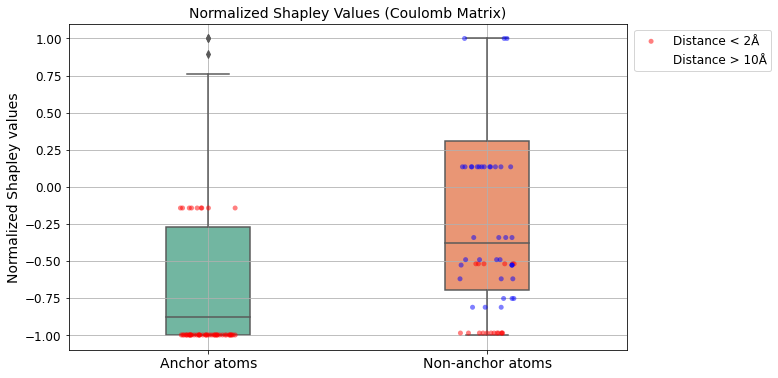

In [26]:
anchor_shapley_values = []
distances_anchor = []
non_anchor_shapley_values = []
distances_non_anchor = []
highlighted_shapley_values_close = []
highlighted_shapley_values_far = []

highlighted_shapley_values_close_non_anchor = []
highlighted_shapley_values_far_non_anchor = []

highlighted_middle_shapley_values = []
highlighted_middle_shapley_values_non_anchor = []

threshold_close = 2  
threshold_close_non_anchor = 2
threshold_far = 10

for i in range(len(data_list)):
    for seed in seed_list:
        anchor_mask = data_dict[i]['anchors'].bool().cpu().numpy()
        fragment_mask = data_dict[i]['fragment_mask'].bool().cpu().numpy()
        anchor_mask = anchor_mask[fragment_mask]
        distances = np.array(data_dict[i][f'distances_{seed}'])
        shapley_values = np.array(data_dict[i][f'normalized_shapley_values_{seed}'])
        
        anchor_shapley_values.extend(shapley_values[anchor_mask])
        distances_anchor.extend(distances[anchor_mask])
        non_anchor_shapley_values.extend(shapley_values[~anchor_mask])
        distances_non_anchor.extend(distances[~anchor_mask])
        # Highlight atoms whose distance is lower than the threshold for anchor atoms
        highlighted_shapley_values_close.extend(np.array(anchor_shapley_values)[np.array(distances_anchor) < threshold_close])
        highlighted_shapley_values_far.extend(np.array(anchor_shapley_values)[np.array(distances_anchor) > threshold_far])

        # Highlight atoms whose distance is lower than the threshold for non-anchor atoms
        highlighted_shapley_values_close_non_anchor.extend(np.array(non_anchor_shapley_values)[np.array(distances_non_anchor) <= threshold_close_non_anchor])
        highlighted_shapley_values_far_non_anchor.extend(np.array(non_anchor_shapley_values)[np.array(distances_non_anchor) >= threshold_far])


# Create box plot using seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=[anchor_shapley_values, non_anchor_shapley_values], palette="Set2", width=0.3)
sns.stripplot(data=[highlighted_shapley_values_close, highlighted_shapley_values_close_non_anchor], color='red', alpha=0.5, label='Distance < 2Å')
sns.stripplot(data=[highlighted_shapley_values_far, highlighted_shapley_values_far_non_anchor], color='blue', alpha=0.5, label='Distance > 10Å')

plt.xticks([0, 1], ['Anchor atoms', 'Non-anchor atoms'], fontsize=14)
plt.ylabel('Normalized Shapley values', fontsize=14)
plt.yticks(fontsize=12)
plt.title('Normalized Shapley Values (Coulomb Matrix)', fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()

unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)


plt.legend(unique_handles, unique_labels, loc='upper right', bbox_to_anchor=(1.27, 1), fontsize=12)

plt.grid(True)
plt.savefig(f"{SAVE_PLOT_FOLDER}box_plot_shapley_value_no_transformations_coulomb_matrix.pdf", bbox_inches='tight', dpi=300)
plt.savefig(f"{SAVE_PLOT_FOLDER}box_plot_shapley_value_no_transformations_coulomb_matrix.png", bbox_inches='tight', dpi=300)

After E(3) transformations

In [27]:
seed = 42
transform_seed_list = [42]
data_dict_transform_transform = copy.deepcopy(data_dict_transform)
for t_seed in transform_seed_list:
    for i in range(NUM_SAMPLES):
        with open(f"{SHAPLEY_VALUE_FOLDER}explanations_seed_{str(seed)}_coulomb_matrix_rotate_translate_reflect/shapley_values/shapley_values_atoms_{i}.txt", "r") as f:
            f.readline()
            f.readline()
            shapley_values = []
            for line in f:
                if line == "\n":
                    break
                row = line.strip().split(",")
                shapley_values.append(float(row[1]))
            dict_key_name = f"shapley_values_{t_seed}"
            data_dict_transform[i][dict_key_name] = shapley_values
        with open(f"{SHAPLEY_VALUE_FOLDER}explanations_seed_{str(seed)}_coulomb_matrix_rotate_translate_reflect/shapley_values/shapley_values_atoms_{i}.txt", "r") as f:
            frobenius_norm_original = None
            frobenius_norm_average = None
            found = False
            while not found:
                line = f.readline()
                if line.startswith("Molecule Frobenius norm"):
                    frobenius_norm_original = float(line.strip().split(":")[1])
                if line.startswith("Average Frobenius norm of random samples"):
                    frobenius_norm_average = float(line.strip().split(":")[1])
                if frobenius_norm_original is not None and frobenius_norm_average is not None:
                    found = True    
            dict_key_name = f"frobenius_norm_original_{seed}"
            data_dict_transform[i][dict_key_name] = frobenius_norm_original
            dict_key_name = f"frobenius_norm_average_{seed}"
            data_dict_transform[i][dict_key_name] = frobenius_norm_average

In [28]:
for t_seed in transform_seed_list:
    for i in range(NUM_SAMPLES):
        with open(f"{POSITIONS_FOLDER}explanations_seed_{str(seed)}_coulomb_matrix_rotate_translate_reflect/mapping/graphs/{i}/{i}_0_.xyz", "r") as f:
            num_atoms = int(f.readline().strip())
            f.readline()
            positions = []*num_atoms
            for line in f:
                row = line.strip().split(" ")[1:]
                coords = [float(x) for x in row]
                positions.append(coords)
            dict_key_name = f"positions_{t_seed}"
            data_dict_transform[i][dict_key_name] = positions

In [29]:
for i in range(len(data_list)):
    linker_mask = data_dict_transform[i]['linker_mask'].bool().cpu().numpy()
    for t_seed in transform_seed_list:
        dict_key_name = f"positions_{t_seed}"
        positions = np.array(data_dict_transform[i][dict_key_name])
        linker_positions = positions[linker_mask.squeeze()]
        com_linker = np.mean(linker_positions, axis=0)
        dict_key_name = f"com_linker_{t_seed}"
        data_dict_transform[i][dict_key_name] = com_linker

In [30]:
for i in range(len(data_list)):
    fragment_mask = data_dict_transform[i]['fragment_mask'].bool().cpu().numpy()
    
    for t_seed in transform_seed_list:
        fragment_positions = np.array(data_dict_transform[i][f'positions_{seed}'])[fragment_mask.squeeze()]
        com_linker = data_dict_transform[i][f'com_linker_{t_seed}']
        distances = np.linalg.norm(fragment_positions - com_linker, axis=1)
        dict_key_name = f'distances_{t_seed}'
        data_dict_transform[i][dict_key_name] = distances

In [31]:
for i in range(len(data_list)):
    for t_seed in transform_seed_list:
        dict_key_name = f"shapley_values_{t_seed}"
        avg_frobenius_norm = data_dict_transform[i][f"frobenius_norm_average_{seed}"]
        original_frobenius_norm = data_dict_transform[i][f"frobenius_norm_original_{seed}"]
        if avg_frobenius_norm > original_frobenius_norm:
            shapley_values = -np.array(data_dict_transform[i][dict_key_name])
        else:
            shapley_values = np.array(data_dict_transform[i][dict_key_name])
        shapley_values = -np.array(data_dict_transform[i][dict_key_name])
        min_val = np.min(shapley_values)
        max_val = np.max(shapley_values)
        normalized_shapley_values = 2 * (shapley_values - min_val) / (max_val - min_val) - 1
        dict_key_name = f"normalized_shapley_values_{t_seed}"
        data_dict_transform[i][dict_key_name] = normalized_shapley_values.tolist()

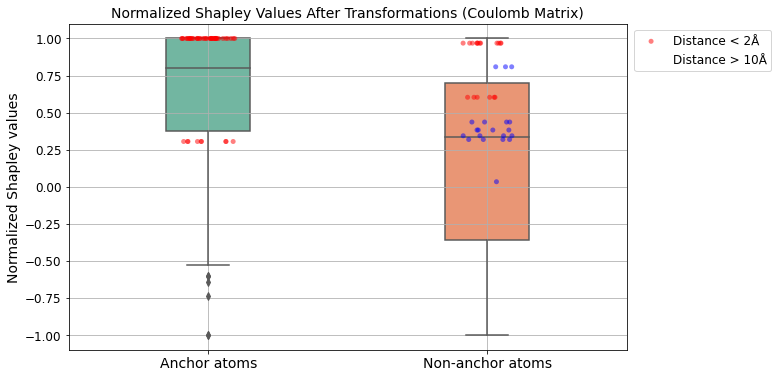

In [32]:
anchor_shapley_values_transform = []
distances_anchor_transform = []
non_anchor_shapley_values_transform = []
distances_non_anchor_transform = []
highlighted_shapley_values_close_transform = []
highlighted_shapley_values_far_transform = []

highlighted_shapley_values_close_transform_non_anchor = []
highlighted_shapley_values_far_non_anchor_transform = []

highlighted_middle_shapley_values_transform = []
highlighted_middle_shapley_values_transform_non_anchor = []

threshold_close = 2 
threshold_close_non_anchor = 2
threshold_far = 10

for i in range(len(data_list)):
    for t_seed in transform_seed_list:
        anchor_mask = data_dict_transform[i]['anchors'].bool().cpu().numpy()
        fragment_mask = data_dict_transform[i]['fragment_mask'].bool().cpu().numpy()
        anchor_mask = anchor_mask[fragment_mask]
        distances = np.array(data_dict_transform[i][f'distances_{t_seed}'])
        shapley_values = np.array(data_dict_transform[i][f'normalized_shapley_values_{t_seed}'])
        
        anchor_shapley_values_transform.extend(shapley_values[anchor_mask])
        distances_anchor_transform.extend(distances[anchor_mask])
        non_anchor_shapley_values_transform.extend(shapley_values[~anchor_mask])
        distances_non_anchor_transform.extend(distances[~anchor_mask])
        # Highlight atoms whose distance is lower than the threshold for anchor atoms
        highlighted_shapley_values_close_transform.extend(np.array(anchor_shapley_values_transform)[np.array(distances_anchor_transform) < threshold_close])
        highlighted_shapley_values_far_transform.extend(np.array(anchor_shapley_values_transform)[np.array(distances_anchor_transform) > threshold_far])

        # Highlight atoms whose distance is lower than the threshold for non-anchor atoms
        highlighted_shapley_values_close_transform_non_anchor.extend(np.array(non_anchor_shapley_values_transform)[np.array(distances_non_anchor_transform) <= threshold_close_non_anchor])
        highlighted_shapley_values_far_non_anchor_transform.extend(np.array(non_anchor_shapley_values_transform)[np.array(distances_non_anchor_transform) >= threshold_far])


plt.figure(figsize=(10, 6))
sns.boxplot(data=[anchor_shapley_values_transform, non_anchor_shapley_values_transform], palette="Set2", width=0.3)

sns.stripplot(data=[highlighted_shapley_values_close_transform, highlighted_shapley_values_close_transform_non_anchor], color='red', alpha=0.5, label='Distance < 2Å')

sns.stripplot(data=[highlighted_shapley_values_far_transform, highlighted_shapley_values_far_non_anchor_transform], color='blue', alpha=0.5, label='Distance > 10Å')

plt.xticks([0, 1], ['Anchor atoms', 'Non-anchor atoms'], fontsize=14)
plt.ylabel('Normalized Shapley values', fontsize=14)
plt.yticks(fontsize=12)
plt.title('Normalized Shapley Values After Transformations (Coulomb Matrix)', fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()


unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)

plt.legend(unique_handles, unique_labels, loc='upper right', bbox_to_anchor=(1.27, 1), fontsize=12)

plt.grid(True)
plt.savefig(f"{SAVE_PLOT_FOLDER}box_plot_shapley_value_e3_transformations_coulomb_matrix.pdf", bbox_inches='tight', dpi=300)
plt.savefig(f"{SAVE_PLOT_FOLDER}box_plot_shapley_value_e3_transformations_coulomb_matrix.png", bbox_inches='tight', dpi=300)

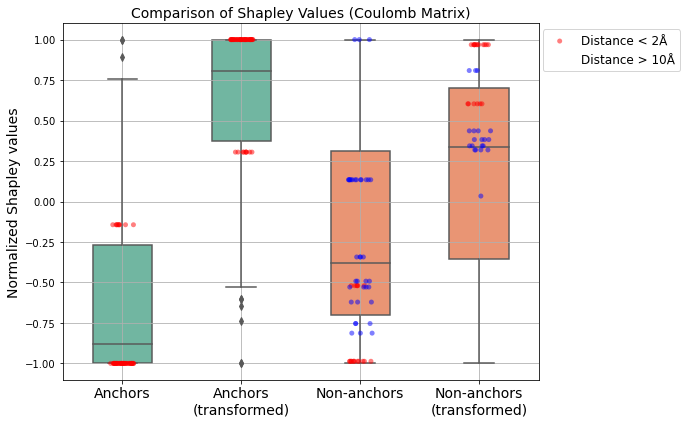

In [33]:
# Create a single plot for comparison
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=[anchor_shapley_values, anchor_shapley_values_transform, non_anchor_shapley_values, non_anchor_shapley_values_transform], 
            palette=[(0.4, 0.76, 0.65, 1), (0.4, 0.76, 0.65, 1), (0.99, 0.55, 0.38, 1), (0.99, 0.55, 0.38, 1)], width=0.5, ax=ax)

sns.stripplot(data=[highlighted_shapley_values_close, highlighted_shapley_values_close_transform, highlighted_shapley_values_close_non_anchor, highlighted_shapley_values_close_transform_non_anchor], color='red', alpha=0.5, label='Distance < 2Å', ax=ax, jitter=True)

sns.stripplot(data=[highlighted_shapley_values_far,  highlighted_shapley_values_far_transform, highlighted_shapley_values_far_non_anchor, highlighted_shapley_values_far_non_anchor_transform], color='blue', alpha=0.5, label='Distance > 10Å', ax=ax, jitter=True)

ax.set_xticks([0, 1,2,3])
ax.set_xticklabels(['Anchors', 'Anchors\n(transformed)', 'Non-anchors', 'Non-anchors\n(transformed)'], fontsize=14)
ax.set_ylabel('Normalized Shapley values', fontsize=14)
ax.set_title('Comparison of Shapley Values (Coulomb Matrix)', fontsize=14)
ax.grid(True)

# Add a shared legend
handles, labels = ax.get_legend_handles_labels()
unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)
ax.legend(unique_handles, unique_labels, loc='upper right', fontsize=12, ncol=1, bbox_to_anchor=(1.31, 1))

# Save and show the plot
plt.tight_layout()
plt.savefig(f"{SAVE_PLOT_FOLDER}comparison_shapley_values_original_vs_transform_coulomb_matrix.pdf", bbox_inches='tight', dpi=300)
plt.savefig(f"{SAVE_PLOT_FOLDER}comparison_shapley_values_original_vs_transform_coulomb_matrix.png", bbox_inches='tight', dpi=300)
plt.show()